Second RNN GridWorld Experiment
Goal: Increase the number of trajectories (batches) used for training in the RNN

Results observation: 

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [24]:
from gridworld import GridWorld, Agent, BasicRNN
import sys
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/seblee/miniconda3/envs/main/bin/python
2.14.0+cu130


State variables

In [25]:

HEIGHT = 20
WIDTH = 25
VIEW_SIZE = 5

START_X = 6
START_Y = 6
START_DIRECTION = 2

N_STEPS = 500

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]

SEED = 42

Gridworld Creation

In [26]:
grid = GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(5, 10, 5, 20)
grid.add_rectangle_region(10, 15, 10, 15)
grid.add_square_shape(6, 6, 3, 7)
grid.add_triangle_shape(6, 11, 3, 0, 6)
grid.add_single_shape(7, 17, 5)
grid.add_single_shape(6, 16, 5)
grid.add_single_shape(6, 18, 5)
grid.add_single_shape(8, 16, 5)
grid.add_single_shape(8, 18, 5)
grid.add_rectangle_shape(11, 12, 3, 1, 3)
grid.add_rectangle_shape(12, 11, 1, 3, 4)


Trajectory Generation Function

In [27]:
def generate_trajectory(grid, start_x, start_y, start_direction, view_size, n_steps, seed):
    
    agent = Agent(start_x, start_y, view_size, grid, start_direction)   #Create agent

    rng = np.random.default_rng(seed)

    for i in range(n_steps):                                            #Agent random walk
        action = rng.choice([0, 1, 2, 3], p=[0.6, 0.15, 0.15, 0.1])

        if action == 0:
            agent.move()
            #print(f"moved towards {agent.direction}")
        elif action == 3:
            agent.stop()
            #print("stopped")
        else:

            agent.rotate(action)
            #print(f"rotated towards {agent.direction}")
        observation = agent.observe()
        #print(pd.DataFrame(observation))

    #print(agent.states)
    print(len(agent.states))
    print(len(agent.observations))
    print(len(agent.actions))

    return agent

Trajectory Data Formatting Function

Now that the input is expanded to also contain the previous step, the data formatting has to be able to accomodate the previous step too

In [28]:
def prepare_data(agent):                                                                #Conversion to tensors
    observations = torch.tensor(
        np.array(agent.observations),
        dtype = torch.float32
    )
    actions = torch.tensor(
        agent.actions, 
        dtype = torch.long
    )
    states = torch.tensor(
        agent.states,
        dtype = torch.long
    )
    print(observations.shape)
    print(actions.shape)
    print(states.shape)
    observations = observations.flatten(start_dim = 1)
    print(observations.shape)
    actions_onehot = torch.nn.functional.one_hot(
        actions,
        num_classes = 4
    ).float()
    print(actions_onehot.shape)
    input_obs = observations[:-1]
    target_obs = observations[1:]
    inputs = torch.cat(
        (input_obs, actions_onehot),
        dim = 1
    )
    print("input observations: ", input_obs.shape)
    print("actions: ", actions_onehot.shape)
    print("NN inputs: ", inputs.shape)
    print("targets: ", target_obs.shape)
    
    return inputs, target_obs

NN Model Creation Function

In [29]:

def model_creation(input_size, output_size, hidden_size):

    model = BasicRNN(input_size, output_size, hidden_size)

    return model

Model Evaluation Function

In [30]:

def model_evaluation(model, observation, inputs, name):

    loss_fn = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        prediction, hidden_sequence = model(inputs)
        test_loss = loss_fn(prediction, observation)
    print(test_loss.item())

    print(f"Test loss, {name}: ", test_loss.item())
    model.train()
    return test_loss.item()

Baseline Evaluation Function

In [31]:

def baseline_evaluation(inputs, targets):
    observation_size = targets.shape[1]

    baseline_prediction = inputs[:, :observation_size]
    loss_fn = nn.MSELoss()
    baseline_loss = loss_fn(baseline_prediction, targets)

    print("Baseline loss: ", baseline_loss.item())


Model Training Function

In [32]:

def model_training(model, input, output):

    loss_fn = nn.MSELoss()

    loss_history = []

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    trainer_error_log = []
    validator_error_log = []
    epochs_recorded = []
    for epoch in range(3000):
        optimizer.zero_grad()
        prediction, hidden_sequence = model(input)

        loss = loss_fn(prediction, output)
        loss_history.append(loss.item())
        loss.backward()

        optimizer.step()

        if epoch % 100 == 0:
            #print(epoch, loss.item())
            trainer_error = model_evaluation(model_RNN, trainer_data_target_obs, trainer_data_inputs, "trainer")
            validator_error = model_evaluation(model_RNN, validator_data_target_obs, validator_data_inputs, "validator")
            trainer_error_log.append(trainer_error)
            validator_error_log.append(validator_error)
            epochs_recorded.append(epoch)
    print(hidden_sequence.shape)
    print(prediction.shape)
    plt.plot(epochs_recorded, trainer_error_log, label = "training")
    plt.plot(epochs_recorded, validator_error_log, label = "test")
    plt.xlabel("epoch")
    plt.ylabel("error")
    plt.legend()
    plt.show()

    return loss_history

NN Training and Validation

501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])


501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])


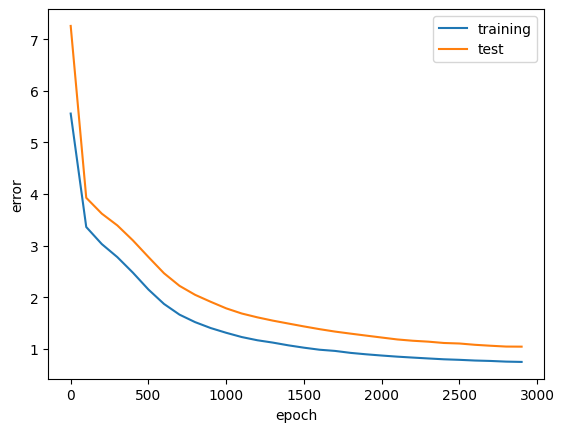

0.6809072494506836
Test loss, trainer:  0.6809072494506836
1.0188359022140503
Test loss, validator:  1.0188359022140503


RuntimeError: The size of tensor a (29) must match the size of tensor b (25) at non-singleton dimension 2

In [33]:

agent_list = []
trainer_rnn_input_list = []
trainer_rnn_target_obs_list = []

for i in range(20):
    trainer_agent = generate_trajectory(grid, START_X, START_Y, START_DIRECTION, VIEW_SIZE, N_STEPS, i)
    agent_list.append(trainer_agent)
    trainer_data_inputs, trainer_data_target_obs = prepare_data(trainer_agent)
    trainer_rnn_input_list.append(trainer_data_inputs)
    trainer_rnn_target_obs_list.append(trainer_data_target_obs)

trainer_rnn_input_stack = torch.stack(
    trainer_rnn_input_list,
    dim = 0
)
trainer_rnn_target_obs_stack = torch.stack(
    trainer_rnn_target_obs_list,
    dim = 0
)
TEST_SEED = 123
TEST_STEPS = 200

validator_agent = generate_trajectory(grid, START_X, START_Y, START_DIRECTION, VIEW_SIZE, TEST_STEPS, TEST_SEED)
validator_data_inputs, validator_data_target_obs = prepare_data(validator_agent)
validator_rnn_inputs = validator_data_inputs.unsqueeze(0)
validator_rnn_target_obs = validator_data_target_obs.unsqueeze(0)

INPUT_SIZE = trainer_rnn_input_stack.shape[2]
OUTPUT_SIZE = trainer_rnn_target_obs_stack.shape[2]
HIDDEN_SIZE = 64     


model_RNN = model_creation(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE)
loss_history = model_training(model_RNN, trainer_rnn_input_stack, trainer_rnn_target_obs_stack)


model_evaluation(model_RNN, trainer_rnn_target_obs_stack, trainer_rnn_input_stack, "trainer")
model_evaluation(model_RNN, validator_data_target_obs, validator_data_inputs, "validator")
baseline_evaluation(validator_rnn_inputs, validator_rnn_target_obs)



validator Error per Action Type

There are t predictions, t + 1 observations and t actions
predictions start from 

In [ ]:
validator_agent_actions = validator_agent.actions
trainer_agent_actions = trainer_agent.actions

validator_action_move = []
validator_action_left = []
validator_action_right = []
validator_action_stop = []
baseline_validator_action_move = []
baseline_validator_action_left = []
baseline_validator_action_right = []
baseline_validator_action_stop = []
trainer_action_move = []
trainer_action_left = []
trainer_action_right = []
trainer_action_stop = []

model_RNN.eval()

with torch.no_grad():
    validator_pred_obs = model_RNN(validator_data_inputs)
    trainer_pred_obs = model_RNN(trainer_data_inputs)

loss_fn = nn.MSELoss(reduction = "none")


validator_loss = loss_fn(validator_data_target_obs, validator_pred_obs)
trainer_loss = loss_fn(trainer_data_target_obs, trainer_pred_obs)

observations_size = validator_data_target_obs.shape[1]
validator_data_target_obs_minusone = validator_data_inputs[:, :observations_size]

baseline_loss = loss_fn(validator_data_target_obs, validator_data_target_obs_minusone)

avg_validator_loss = validator_loss.mean(dim = 1)
avg_trainer_loss = trainer_loss.mean(dim = 1)

i = 0
for actions in validator_agent_actions:
    if actions == 0:
        validator_action_move.append(avg_validator_loss[i])
        baseline_validator_action_move.append(baseline_loss[i])
    elif actions == 1:
        validator_action_left.append(avg_validator_loss[i])
        baseline_validator_action_left.append(baseline_loss[i])
    elif actions == 2:
        validator_action_right.append(avg_validator_loss[i])
        baseline_validator_action_right.append(baseline_loss[i])
    elif actions == 3:
        validator_action_stop.append(avg_validator_loss[i])
        baseline_validator_action_stop.append(baseline_loss[i])
    i += 1

j = 0
for actions in trainer_agent_actions:
    if actions == 0:
        trainer_action_move.append(avg_trainer_loss[j])
    elif actions == 1:
        trainer_action_left.append(avg_trainer_loss[j])
    elif actions == 2:
        trainer_action_right.append(avg_trainer_loss[j])
    elif actions == 3:
        trainer_action_stop.append(avg_trainer_loss[j])
    j += 1

validator_move_loss = torch.stack(validator_action_move).mean()
validator_left_loss = torch.stack(validator_action_left).mean()
validator_right_loss = torch.stack(validator_action_right).mean()
validator_stop_loss = torch.stack(validator_action_stop).mean()
trainer_move_loss = torch.stack(trainer_action_move).mean()
trainer_left_loss = torch.stack(trainer_action_left).mean()
trainer_right_loss = torch.stack(trainer_action_right).mean()
trainer_stop_loss = torch.stack(trainer_action_stop).mean()
baseline_move_loss = torch.stack(baseline_validator_action_move).mean()
baseline_left_loss = torch.stack(baseline_validator_action_left).mean()
baseline_right_loss = torch.stack(baseline_validator_action_right).mean()
baseline_stop_loss = torch.stack(baseline_validator_action_stop).mean()

print(f"move loss: {validator_move_loss}, {len(validator_action_move)}")
print(f"left loss: {validator_left_loss}, {len(validator_action_left)}")
print(f"right loss: {validator_right_loss}, {len(validator_action_right)}")
print(f"stop loss: {validator_stop_loss}, {len(validator_action_stop)}")

print(f"trainer move loss: {trainer_move_loss}, {len(trainer_action_move)}")
print(f"trainer left loss: {trainer_left_loss}, {len(trainer_action_left)}")
print(f"trainer right loss: {trainer_right_loss}, {len(trainer_action_right)}")
print(f"trainer stop loss: {trainer_stop_loss}, {len(trainer_action_stop)}")

print(f"baseline_move loss: {baseline_move_loss}, {len(baseline_validator_action_move)}")
print(f"baseline_left loss: {baseline_left_loss}, {len(baseline_validator_action_left)}")
print(f"baseline_right loss: {baseline_right_loss}, {len(baseline_validator_action_right)}")
print(f"baseline_stop loss: {baseline_stop_loss}, {len(baseline_validator_action_stop)}")


validator_global_avg_loss = (validator_move_loss * len(validator_action_move) + validator_left_loss * len(validator_action_left) + validator_right_loss * len(validator_action_right) + validator_stop_loss * len(validator_action_stop)) / 200
trainer_global_avg_loss = (trainer_move_loss * len(trainer_action_move) + trainer_left_loss * len(trainer_action_left) + trainer_right_loss * len(trainer_action_right) + trainer_stop_loss * len(trainer_action_stop)) / 500

print(f"validator Global Average Loss: {validator_global_avg_loss}")
print(f"Trainer Global Average Loss: {trainer_global_avg_loss}")



A Standard NN is memoryless, so if for two different states, the same observation is presented and the same action is chosen, the input to the NN are effectively the same, with no distinguishability. The next goal is to show that this is an issue with standard MLPs.

Find scenarios where (o_t, a_t) are equal but o_t+1 are different at the next step. then compare the predicted o_t+1 and see how similar they are one to the other

In [ ]:
trainer_validator_inputs = torch.cat((trainer_data_inputs, validator_data_inputs), dim = 0)
equal_input_pairs = []

groups = {}

for i in range(len(trainer_validator_inputs)):
    key = tuple(trainer_validator_inputs[i].tolist())

    if key not in groups:
        groups[key] = []

    groups[key].append(i)

multiinput_count = 0
oneinput_count = 0
for key, number in groups.items():
    if len(number) > 1:
        print(number)
        multiinput_count += 1
    else:
        oneinput_count += 1
    if len(number) == 2:
        print(f"occurences: {len(number)}")

        key_tensor = torch.tensor(key)
        observation = key_tensor[:25].reshape(5, 5)
        action = key_tensor[25:]

        #print(observation)
        #print(action)

#print(multiinput_count)
#print(oneinput_count)


Consider which equal scenarios contain a different next observation, and also compare with predicted observation

In [ ]:
trainer_validator_target_obs = torch.cat((trainer_data_target_obs, validator_data_target_obs), dim = 0)


for key, indices in groups.items():
    if len(indices) > 1:
        matching_set = set()
        for i in indices:
            target_key = tuple(trainer_validator_target_obs[i].tolist())
            matching_set.add(target_key)

        print(f"Occurences: {len(indices)}")
        print(f"Matching sets: {(len(matching_set))}")
        print(f"Indices: {indices}")



